In [14]:
import re
import warnings
import joblib
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import ComplementNB
from sklearn.ensemble import VotingClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.pipeline import Pipeline
from scipy.sparse import hstack
from imblearn.over_sampling import ADASYN

from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

warnings.filterwarnings('ignore')
RANDOM_STATE = 42

CLEANING DATA

In [15]:
df = pd.read_csv('data_label.csv', sep=';')

df.head()

,text,label
0,Kunjungan Prabowo ini untuk meresmikan dan men...,Sumber Daya Alam
1,RT Anies dapat tepuk tangan meriah saat jadi R...,Politik
2,@CIqXqwGAT04tMtx4OCATxjoVq7vv/Y8HeYaIOgMFg8Y= ...,Demografi
3,RT @L3R8XFBw3WGbxRPSj0/0hHZTbqVGX7qtfwRg9zmhK7...,Politik
4,Anies Baswedan Harap ASN termasuk TNI dan Polr...,Politik


In [16]:
# cek duplikasi
df.shape

(5000, 2)

In [17]:
# drop semua yg duplikat
df = df.drop_duplicates(subset=['text'])
df.duplicated().sum()

np.int64(0)

In [18]:
df = df.dropna()

In [19]:
df.isnull().sum()

text     0
label    0
dtype: int64

delete noise

In [20]:
def clean_twitter_text(text):
    text = re.sub(r'@[A-Za-z0-9_]+', '', text) #hapus mention
    text = re.sub(r'#\w+', '', text) #hapus hashtag
    text = re.sub(r'https?://\S+', '', text) #hapus URL
    text = re.sub(r'[^A-Za-z0-9\s]+', '', text) #hapus karakter khusus
    text = re.sub(r'\s+', ' ', text).strip() #hapus spasi berlebih
    text = re.sub(r'RT[\s]+', '', text) #hapus RT
    text = re.sub(r'RE[\s]+', '', text) #hapus RE
    return text

df['text'] = df['text'].apply(clean_twitter_text)


In [21]:
df['text'] = df['text'].str.lower()

In [22]:
df

,text,label
0,kunjungan prabowo ini untuk meresmikan dan men...,Sumber Daya Alam
1,anies dapat tepuk tangan meriah saat jadi rekt...,Politik
2,y8heyaiogmfg8y emng bener sih pendukung 01 ada...,Demografi
3,0hhztbqvgx7qtfwrg9zmhk7q sewaktu anies bersika...,Politik
4,anies baswedan harap asn termasuk tni dan polr...,Politik
...,...,...
4995,ngeliat debat kemaren pas prabowo kicep kekira...,Politik
4996,masyarakat yakin bahwa prabowogibran memiliki ...,Politik
4997,imo both are irrational but yg satu jauh lebih...,Ekonomi
4998,look at that pak ganjar anda sdh berkecimpung ...,Pertahanan dan Keamanan


load slang dict

In [23]:
try:
    slang_df   = pd.read_csv('slang_indo.csv', header=None, names=['slang','formal'])
    slang_dict = dict(zip(slang_df['slang'], slang_df['formal']))
    print(f'Slang loaded: {len(slang_dict)} entri')
    print(f'Contoh: {list(slang_dict.items())[:5]}')
except FileNotFoundError:
    slang_dict = {}
    print('File slang tidak ditemukan, lanjut tanpa normalisasi slang')

Slang loaded: 1250 entri
Contoh: [('aamiin', 'amin '), ('adek', 'adik '), ('adlh', 'adalah '), ('aer', 'air '), ('aiskrim', 'es krim ')]


prepo, init stemmer + stopword

In [24]:
# Stemmer dengan cache supaya cepat
factory = StemmerFactory()
stemmer = factory.create_stemmer()

stem_cache = {}
def cached_stem(word):
    if word not in stem_cache:
        stem_cache[word] = stemmer.stem(word)
    return stem_cache[word]

# Stopword default Sastrawi langsung pakai
sw_factory    = StopWordRemoverFactory()
stopword_list = set(sw_factory.get_stop_words())

# Tambah noise twitter
noise_words = {'amp','via','share','http','co','re','rt'}
stopword_list = stopword_list | noise_words

print(f'Stopword aktif: {len(stopword_list)} kata')

Stopword aktif: 130 kata


func preprocessing

In [25]:
df

,text,label
0,kunjungan prabowo ini untuk meresmikan dan men...,Sumber Daya Alam
1,anies dapat tepuk tangan meriah saat jadi rekt...,Politik
2,y8heyaiogmfg8y emng bener sih pendukung 01 ada...,Demografi
3,0hhztbqvgx7qtfwrg9zmhk7q sewaktu anies bersika...,Politik
4,anies baswedan harap asn termasuk tni dan polr...,Politik
...,...,...
4995,ngeliat debat kemaren pas prabowo kicep kekira...,Politik
4996,masyarakat yakin bahwa prabowogibran memiliki ...,Politik
4997,imo both are irrational but yg satu jauh lebih...,Ekonomi
4998,look at that pak ganjar anda sdh berkecimpung ...,Pertahanan dan Keamanan


In [26]:
# 1. Ada gak hasil cleaning yang jadi kosong?
df[df['text'].str.strip() == '']



,text,label


In [27]:
df = df[df['text'].str.strip() != '']


In [28]:
df = df.reset_index(drop=True)


In [29]:
print(f"Data tersisa: {df.shape[0]} baris")
print(f"Cek kosong lagi: {(df['text'].str.strip() == '').sum()} baris")

Data tersisa: 4583 baris
Cek kosong lagi: 0 baris


In [30]:
# Lihat teks yang sangat panjang
df[df['text'].str.len() > 1000][['text', 'label']].head(100)

,text,label
64,konsisten selama ini bersuara melawan radikali...,Demografi
275,mantan ketua komnas ham apresiasi polri buka r...,Sosial Budaya
276,menjelang tengah malam ini aku mau ucapkan ter...,Politik
349,ganjarmahfud md program kuliah gratis bagi ana...,Demografi
359,serba terantuk ke sana sini terjebak akibat ak...,Politik
...,...,...
4001,menjegal videotron anies baswedan hanya bagian...,Politik
4014,sampai kapan kubu prabowo bodohi rakyat oleh t...,Politik
4021,pemerintah harus menggandeng masyarakat dari a...,Sumber Daya Alam
4276,koalisi anies ganjar pada awalnya sih malu mal...,Politik


In [31]:
# Lihat distribusi label dari teks panjang ini
df[df['text'].str.len() > 1000]['label'].value_counts()

label
Politik                    28
Sosial Budaya              10
Ideologi                    9
Ekonomi                     7
Pertahanan dan Keamanan     3
Demografi                   2
Sumber Daya Alam            2
Name: count, dtype: int64

In [32]:
# Truncate teks yang lebih dari 500 karakter
df['text'] = df['text'].apply(lambda x: x[:500] if len(x) > 500 else x)

# Verifikasi
print(f"Max panjang sekarang: {df['text'].str.len().max()}")
print(f"Total data: {df.shape[0]}")

Max panjang sekarang: 500
Total data: 4583


label encoding + split data

In [34]:
le = LabelEncoder()
df['label_enc'] = le.fit_transform(df['label'])
print('Kelas:', le.classes_)

X_train, X_test, y_train, y_test = train_test_split(
    df['text'].values,
    df['label_enc'].values,
    test_size    = 0.2,
    stratify     = df['label_enc'].values,
    random_state = RANDOM_STATE
)
print(f'Train: {len(X_train)} | Test: {len(X_test)}')

Kelas: ['Demografi' 'Ekonomi' 'Geografi' 'Ideologi' 'Pertahanan dan Keamanan'
 'Politik' 'Sosial Budaya' 'Sumber Daya Alam']
Train: 3666 | Test: 917


tf-idf word + char

In [35]:
from scipy.sparse import hstack

word_tfidf = TfidfVectorizer(
    analyzer     = 'word',
    ngram_range  = (1, 2),
    min_df       = 2,
    max_df       = 0.85,
    sublinear_tf = True,
    max_features = 15000,
    strip_accents = 'unicode'
)
char_tfidf = TfidfVectorizer(
    analyzer     = 'char_wb',
    ngram_range  = (3, 5),
    min_df       = 2,
    max_df       = 0.85,
    sublinear_tf = True,
    max_features = 10000,
    strip_accents = 'unicode'
)

X_train_vec = hstack([
    word_tfidf.fit_transform(X_train),
    char_tfidf.fit_transform(X_train)
])
X_test_vec = hstack([
    word_tfidf.transform(X_test),
    char_tfidf.transform(X_test)
])

print(f'Shape train : {X_train_vec.shape}')
print(f'Shape test  : {X_test_vec.shape}')
print(f'Total fitur : {X_train_vec.shape[1]:,}')

Shape train : (3666, 24403)
Shape test  : (917, 24403)
Total fitur : 24,403


adasyn

In [36]:
from imblearn.over_sampling import ADASYN

# Cek distribusi sebelum
print('Distribusi sebelum ADASYN:')
for cls_idx, cls_name in enumerate(le.classes_):
    print(f'  {cls_name:35s}: {(y_train == cls_idx).sum()}')

# ADASYN hanya untuk kelas minoritas
class_counts = np.bincount(y_train)
k_neighbors  = max(1, min(5, class_counts.min() - 1))

try:
    adasyn = ADASYN(
        sampling_strategy = 'minority',
        random_state      = RANDOM_STATE,
        n_neighbors       = k_neighbors
    )
    X_train_res, y_train_res = adasyn.fit_resample(X_train_vec, y_train)
    print('\nDistribusi setelah ADASYN:')
    for cls_idx, cls_name in enumerate(le.classes_):
        print(f'  {cls_name:35s}: {(y_train_res == cls_idx).sum()}')
except Exception as e:
    X_train_res, y_train_res = X_train_vec, y_train
    print(f'ADASYN gagal: {e}, lanjut tanpa oversampling')

Distribusi sebelum ADASYN:
  Demografi                          : 48
  Ekonomi                            : 247
  Geografi                           : 16
  Ideologi                           : 271
  Pertahanan dan Keamanan            : 264
  Politik                            : 2362
  Sosial Budaya                      : 335
  Sumber Daya Alam                   : 123

Distribusi setelah ADASYN:
  Demografi                          : 48
  Ekonomi                            : 247
  Geografi                           : 2356
  Ideologi                           : 271
  Pertahanan dan Keamanan            : 264
  Politik                            : 2362
  Sosial Budaya                      : 335
  Sumber Daya Alam                   : 123


ensemble training

In [48]:
from sklearn.calibration import CalibratedClassifierCV
from sklearn.utils.class_weight import compute_class_weight

# Hitung class weight dari data setelah ADASYN
weights = compute_class_weight(
    class_weight = 'balanced',
    classes      = np.unique(y_train_res),
    y            = y_train_res
)

# Kurangi dominasi Politik
politik_idx           = list(le.classes_).index('Politik')
weights[politik_idx] *= 0.6
weight_dict           = dict(enumerate(weights))
print('Class weights:', weight_dict)

# Definisi tiap model
svm = CalibratedClassifierCV(
    LinearSVC(C=5.0, class_weight=weight_dict, max_iter=2000, random_state=RANDOM_STATE)
)
lr = LogisticRegression(
    C            = 10.0,
    class_weight = weight_dict,
    max_iter     = 1000,
    solver       = 'saga',
    random_state = RANDOM_STATE
)
cnb = ComplementNB(alpha=0.3)

# Voting ensemble
ensemble = VotingClassifier(
    estimators = [('svm', svm), ('lr', lr), ('cnb', cnb)],
    voting     = 'soft'
)

print('Training ensemble...')
ensemble.fit(X_train_res, y_train_res)
print('✅ Ensemble selesai ditraining')

Class weights: {0: np.float64(15.640625), 1: np.float64(3.039473684210526), 2: np.float64(0.31865449915110355), 3: np.float64(2.7702952029520294), 4: np.float64(2.84375), 5: np.float64(0.19070702794242167), 6: np.float64(2.241044776119403), 7: np.float64(6.103658536585366)}
Training ensemble...
✅ Ensemble selesai ditraining


─── Classification Report ───
                         precision    recall  f1-score   support

              Demografi       0.18      0.17      0.17        12
                Ekonomi       0.69      0.65      0.67        62
               Geografi       0.00      0.00      0.00         4
               Ideologi       0.81      0.56      0.66        68
Pertahanan dan Keamanan       0.74      0.44      0.55        66
                Politik       0.79      0.94      0.86       590
          Sosial Budaya       0.53      0.29      0.37        84
       Sumber Daya Alam       0.67      0.19      0.30        31

               accuracy                           0.76       917
              macro avg       0.55      0.40      0.45       917
           weighted avg       0.74      0.76      0.73       917

Akurasi: 0.7579


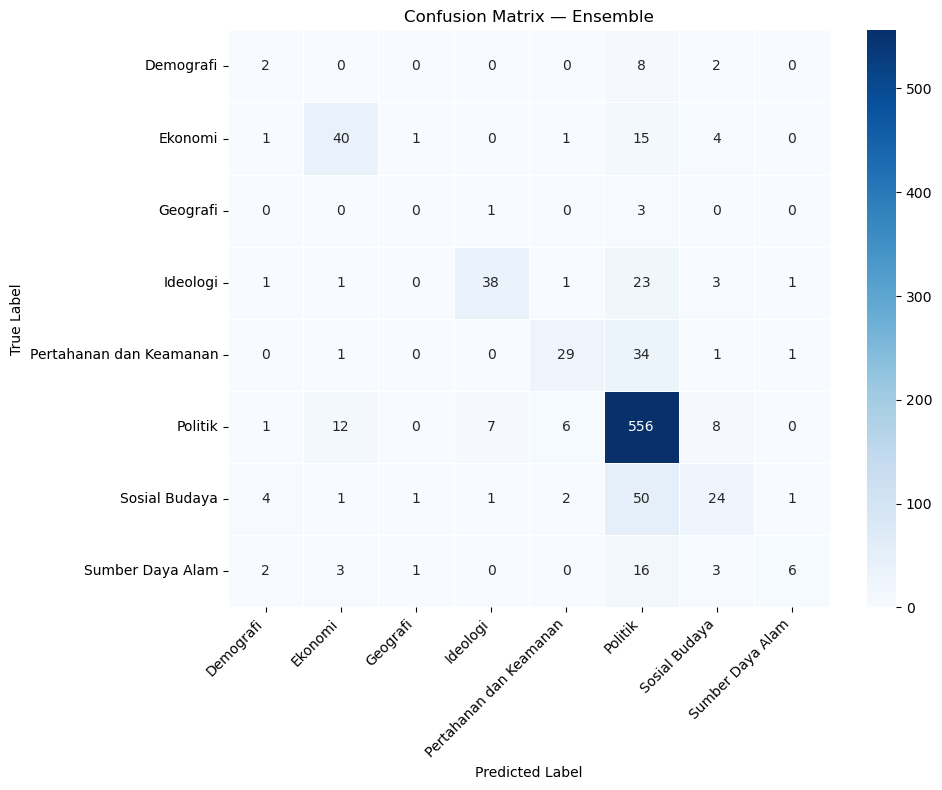

In [49]:
pred = ensemble.predict(X_test_vec)

print('─── Classification Report ───')
print(classification_report(y_test, pred, target_names=le.classes_))
print(f'Akurasi: {(pred == y_test).mean():.4f}')

# Confusion Matrix
cm = confusion_matrix(y_test, pred)
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    cm, annot=True, fmt='d',
    xticklabels=le.classes_,
    yticklabels=le.classes_,
    cmap='Blues', ax=ax, linewidths=0.5
)
ax.set_title('Confusion Matrix — Ensemble')
ax.set_ylabel('True Label')
ax.set_xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

pred 50k

In [ ]:
# # ── Prediksi Data Unlabel 50k ─────────────────────────

# # Load
# df_unlabel = pd.read_csv('data_unlabel.csv', sep=';')
# print(f'Shape awal: {df_unlabel.shape}')

# # Cleaning — pakai fungsi yang sama dengan training
# df_unlabel['text'] = df_unlabel['text'].apply(clean_twitter_text)
# df_unlabel['text'] = df_unlabel['text'].str.lower()

# # Preprocessing — cache stem sudah terisi dari training
# # kata yang sama tidak diproses ulang
# print(f'Cache stem tersedia: {len(stem_cache)} kata')
# print('Preprocessing data unlabel...')
# df_unlabel['clean_text'] = df_unlabel['text'].apply(preprocess)

# # Drop kosong
# empty = df_unlabel['clean_text'].str.strip() == ''
# print(f'Tweet kosong: {empty.sum()}')
# df_unlabel = df_unlabel[~empty].reset_index(drop=True)
# print(f'Data tersisa: {len(df_unlabel)}')

# # Vectorize — TIDAK fit ulang, langsung transform
# print('Vectorizing...')
# X_unlabel_vec = hstack([
#     word_tfidf.transform(df_unlabel['clean_text']),
#     char_tfidf.transform(df_unlabel['clean_text'])
# ])

# # Prediksi dalam batch supaya tidak OOM
# print('Prediksi...')
# BATCH_SIZE = 5000
# preds      = []
# probas     = []

# for i in range(0, X_unlabel_vec.shape[0], BATCH_SIZE):
#     batch      = X_unlabel_vec[i:i+BATCH_SIZE]
#     preds.append(ensemble.predict(batch))
#     probas.append(ensemble.predict_proba(batch).max(axis=1))
#     print(f'  Batch {i//BATCH_SIZE + 1} selesai ({min(i+BATCH_SIZE, X_unlabel_vec.shape[0])}/{X_unlabel_vec.shape[0]})')

# df_unlabel['predicted_label'] = le.inverse_transform(np.concatenate(preds))
# df_unlabel['confidence']      = np.concatenate(probas).round(4)

# # Distribusi hasil
# print('\nDistribusi prediksi:')
# dist     = df_unlabel['predicted_label'].value_counts()
# dist_pct = df_unlabel['predicted_label'].value_counts(normalize=True) * 100
# for label, cnt in dist.items():
#     bar = '█' * int(dist_pct[label] / 2)
#     print(f'  {label:35s}: {cnt:5d} ({dist_pct[label]:4.1f}%) {bar}')

# # Simpan
# df_unlabel[['text','clean_text','predicted_label','confidence']].to_csv(
#     'hasil_prediksi_unlabel.csv', index=False, sep=';'
# )
# print('\n✅ Disimpan ke hasil_prediksi_unlabel.csv')
# df_unlabel[['text','clean_text','predicted_label','confidence']].head(10)

Shape awal: (1000, 2)
Cache stem tersedia: 1247 kata
Preprocessing data unlabel...


KeyboardInterrupt: 